In [5]:
from pathlib import Path
import numpy as np
import mne

SUBJECT = '01'
SESSION = '01'
TASK    = 'Cannonball MF'

PROJECT_ROOT    = Path('..').resolve()
DERIVATIVES_DIR = PROJECT_ROOT / 'data' / 'derivatives' / 'mne_preproc'
sub_ses_dir     = DERIVATIVES_DIR / f'sub-{SUBJECT}' / f'ses-{SESSION}'
EPOCHS_PATH     = sub_ses_dir / f'sub-{SUBJECT}_ses-{SESSION}_task-{TASK}_epochs_feedback_clean-epo.fif'

ANTICI_TMIN = -0.5
ANTICI_TMAX =  0.0
EDGE_CROP   =  0.05          # seconds to trim from each end after cropping

epochs = mne.read_epochs(str(EPOCHS_PATH), preload=True, verbose=False)
epochs = epochs.pick('eeg')  # raw voltage, all EEG channels
epochs = epochs.crop(
    tmin=ANTICI_TMIN + EDGE_CROP,
    tmax=ANTICI_TMAX - EDGE_CROP
)

print(f'Epochs loaded : {len(epochs)}')
print(f'Conditions    : {list(epochs.event_id.keys())}')
print(f'Time window   : {epochs.tmin:.3f} to {epochs.tmax:.3f} s')
print(f'n_channels    : {len(epochs.ch_names)}')
print(f'n_times       : {len(epochs.times)}')

Epochs loaded : 713
Conditions    : ['loss', 'reward']
Time window   : -0.449 to -0.051 s
n_channels    : 66
n_times       : 103


In [6]:
# Build X (trials × channels × times) and y (reward=1, loss=0)

reward_epochs = epochs['reward']
loss_epochs   = epochs['loss']

X = np.concatenate([
    reward_epochs.get_data(),   # (n_reward, n_ch, n_times)
    loss_epochs.get_data()      # (n_loss,   n_ch, n_times)
], axis=0)

y = np.concatenate([
    np.ones(len(reward_epochs)),
    np.zeros(len(loss_epochs))
])

times = epochs.times

print(f'X shape : {X.shape}  (trials × channels × times)')
print(f'y shape : {y.shape}  — {int(y.sum())} reward, {int((y==0).sum())} loss')

X shape : (713, 66, 103)  (trials × channels × times)
y shape : (713,)  — 453 reward, 260 loss


In [7]:
from mne.decoding import GeneralizingEstimator, cross_val_multiscore
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold

clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=1)
)

gen = GeneralizingEstimator(
    clf,
    scoring='roc_auc',
    n_jobs=1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scores shape: (n_folds, n_train_times, n_test_times)
scores = cross_val_multiscore(gen, X, y, cv=cv, n_jobs=1)
scores_mean = scores.mean(axis=0)

print(f'TGM shape : {scores_mean.shape}')
print(f'AUC range : {scores_mean.min():.3f} – {scores_mean.max():.3f}')

/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Fitting GeneralizingEstimator : 103/103 [00:05<00:00,   17.63it/s]
100%|██████████| Scoring GeneralizingEstimator : 10609/10609 [00:18<00:00,  577.25it/s]
100%|██████████| Fitting GeneralizingEstimator : 103/103 [00:06<00:00,   17.01it/s]
100%|██████████| Scoring GeneralizingEstimator : 10609/10609 [00:18<00:00,  582.33it/s]
100%|██████████| Fitting GeneralizingEstimator : 103/103 [00:06<00:00,   16.75it/s]
100%|██████████| Scoring GeneralizingEstimator : 10609/10609 [00:18<00:00,  584.28it/s]
100%|██████████| Fitting GeneralizingEstimator : 103/103 [00:06<00:00,   16.82it/s]
100%|██████████| Scoring GeneralizingEstimator : 10609/10609 [00:18<00:00,  571.07it/s]
100%|██████████| Fitting Generalizing

TGM shape : (103, 103)
AUC range : 0.425 – 0.634


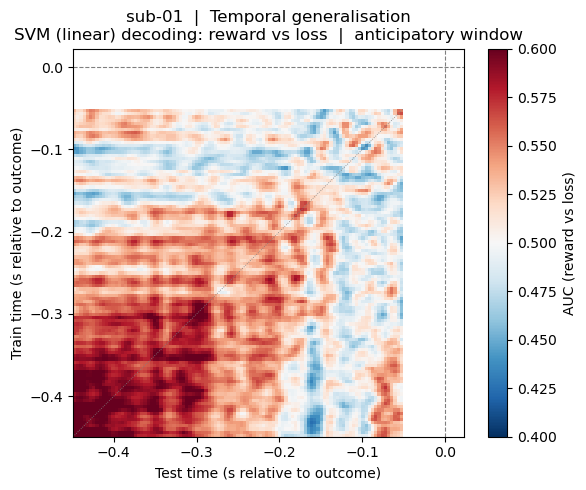

Traceback (most recent call last):
  File "/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-73690-nb6ojc0u for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-73690-jsxwty2x for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
       

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    scores_mean,
    origin='lower',
    extent=[times[0], times[-1], times[0], times[-1]],
    aspect='auto',
    vmin=0.4, vmax=0.6,
    cmap='RdBu_r'
)
fig.colorbar(im, ax=ax, label='AUC (reward vs loss)')

# Chance line
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)

# Diagonal (train == test time)
ax.plot(times, times, color='gray', linewidth=0.6, linestyle=':')

ax.set_xlabel('Test time (s relative to outcome)')
ax.set_ylabel('Train time (s relative to outcome)')
ax.set_title(
    f'sub-{SUBJECT}  |  Temporal generalisation\n'
    f'SVM (linear) decoding: reward vs loss  |  anticipatory window'
)
plt.tight_layout()
plt.show()

In [ ]:
# Save TGM results for between-subjects averaging
tgm_path = sub_ses_dir / f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}_tgm_results.npz"

np.savez(
    str(tgm_path),
    subject      = SUBJECT,
    scores_mean  = scores_mean,
    scores_all   = scores,       # (n_folds, n_train, n_test) — keep folds for group-level stats
    times        = times,
)
print(f"Saved TGM results → {tgm_path}")